In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# --- paths ---
ROOT = Path("../outputs")
EXP  = ROOT / "experiments"
MET  = ROOT / "metrics" / "comprehensive"
SHAP = ROOT / "analysis" / "shap"

def load(p):
    with open(p) as f:
        return json.load(f)

# load all results
ablation   = load(EXP / "ablation_injury" / "ablation_summary.json")
twohead    = load(EXP / "twohead" / "summary.json")
pos_spec   = load(EXP / "position_specific" / "summary.json")
stacked    = load(EXP / "stacked_ensemble" / "summary.json")
shap_data  = load(SHAP / "baseline_shap_report.json")

comp_baseline = load(MET / "baseline_comprehensive.json")
comp_stacked  = load(MET / "stacked_ensemble_comprehensive.json")
comp_twohead  = load(MET / "twohead_comprehensive.json")
comp_posspec  = load(MET / "position_specific_comprehensive.json")

# --- style ---
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "text.color": "#333333",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.color": "#cccccc",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

PAL = ["#10B981", "#3B82F6", "#F59E0B", "#EF4444", "#8B5CF6", "#EC4899"]
print("Loaded all experiment data.")

Loaded all experiment data.


## Figure 1 — Architecture Comparison (MAE)

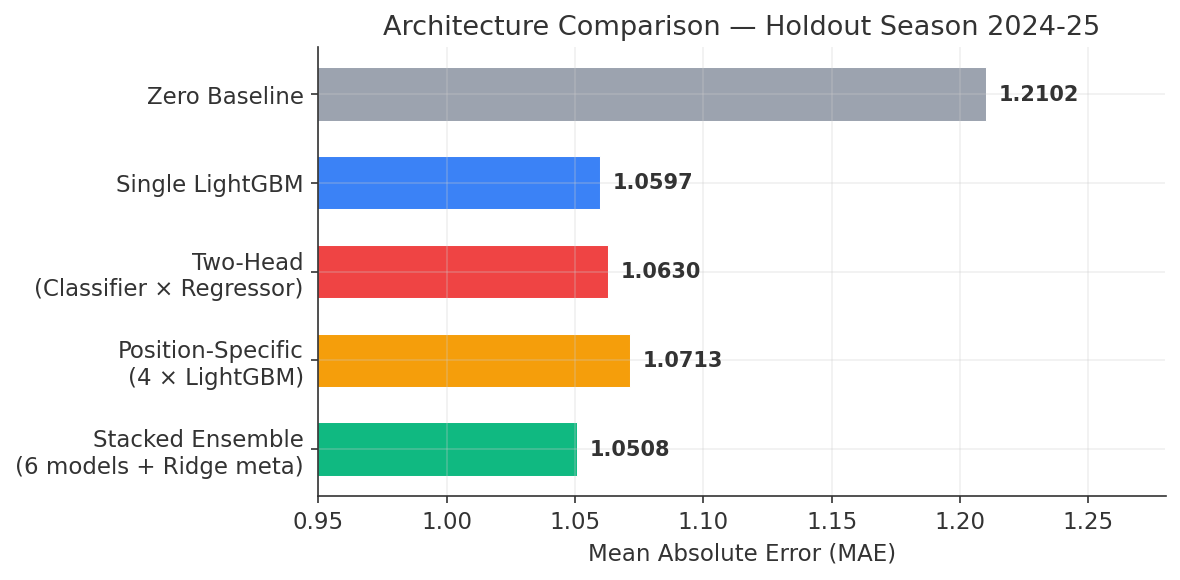

In [3]:
models = [
    "Zero Baseline",
    "Single LightGBM",
    "Two-Head\n(Classifier × Regressor)",
    "Position-Specific\n(4 × LightGBM)",
    "Stacked Ensemble\n(6 models + Ridge meta)",
]
maes = [
    1.2102,   # zero baseline
    comp_baseline["stratified"]["mae_overall"],
    comp_twohead["stratified"]["mae_overall"],
    comp_posspec["stratified"]["mae_overall"],
    comp_stacked["stratified"]["mae_overall"],
]
colors = ["#9CA3AF", PAL[1], PAL[3], PAL[2], PAL[0]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(models, maes, color=colors, height=0.6, edgecolor="white", linewidth=0.5)

for bar, v in zip(bars, maes):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.4f}",
            va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Mean Absolute Error (MAE)")
ax.set_title("Architecture Comparison — Holdout Season 2024-25")
ax.set_xlim(0.95, 1.28)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../outputs/figures/fig1_architecture_comparison.png")
plt.show()

## Figure 2 — Stacked Ensemble: Base Model Breakdown

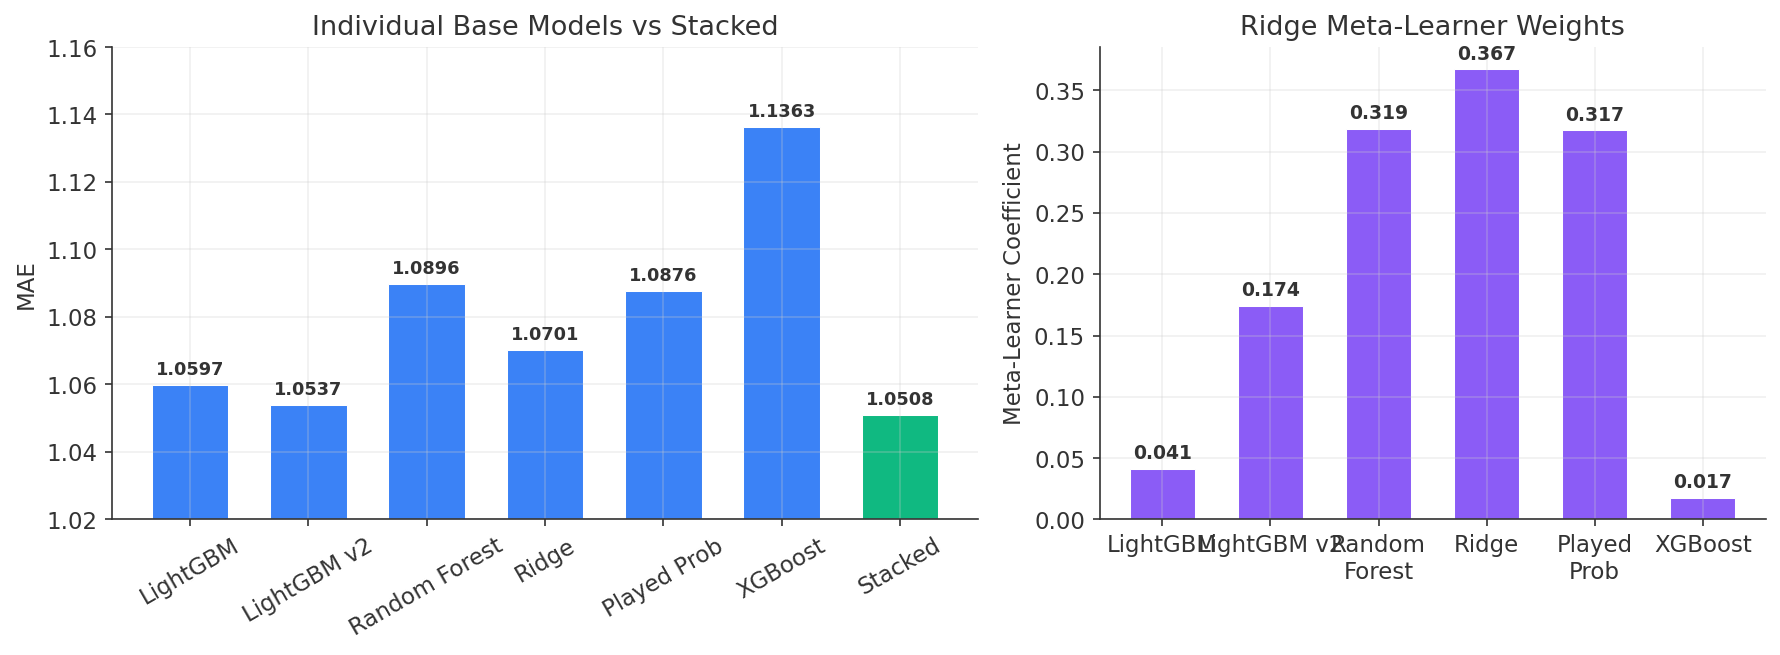

In [4]:
base_names = ["LightGBM", "LightGBM v2", "Random Forest", "Ridge", "Played Prob", "XGBoost", "Stacked"]
base_keys  = ["lgbm", "lgbm_v2", "rf", "ridge", "played_prob", "xgb", "stacked"]
base_maes  = [stacked["all_methods"][k]["mae"] for k in base_keys]
base_colors = [PAL[1]]*6 + [PAL[0]]

meta_names = ["LightGBM", "LightGBM v2", "Random\nForest", "Ridge", "Played\nProb", "XGBoost"]
meta_keys  = ["lgbm", "lgbm_v2", "rf", "ridge", "played_prob", "xgb"]
meta_w     = [stacked["meta_coefficients"][k] for k in meta_keys]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.3, 1]})

# left: MAE comparison
bars1 = ax1.bar(base_names, base_maes, color=base_colors, width=0.65, edgecolor="white", linewidth=0.5)
for bar, v in zip(bars1, base_maes):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.4f}",
             ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax1.set_ylabel("MAE")
ax1.set_title("Individual Base Models vs Stacked")
ax1.set_ylim(1.02, 1.16)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(axis="x", rotation=30)

# right: meta-learner weights
bars2 = ax2.bar(meta_names, meta_w, color=PAL[4], width=0.6, edgecolor="white", linewidth=0.5)
for bar, v in zip(bars2, meta_w):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_ylabel("Meta-Learner Coefficient")
ax2.set_title("Ridge Meta-Learner Weights")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig("../outputs/figures/fig2_stacked_ensemble_breakdown.png")
plt.show()

## Figure 3 — Position-Specific vs Unified Model

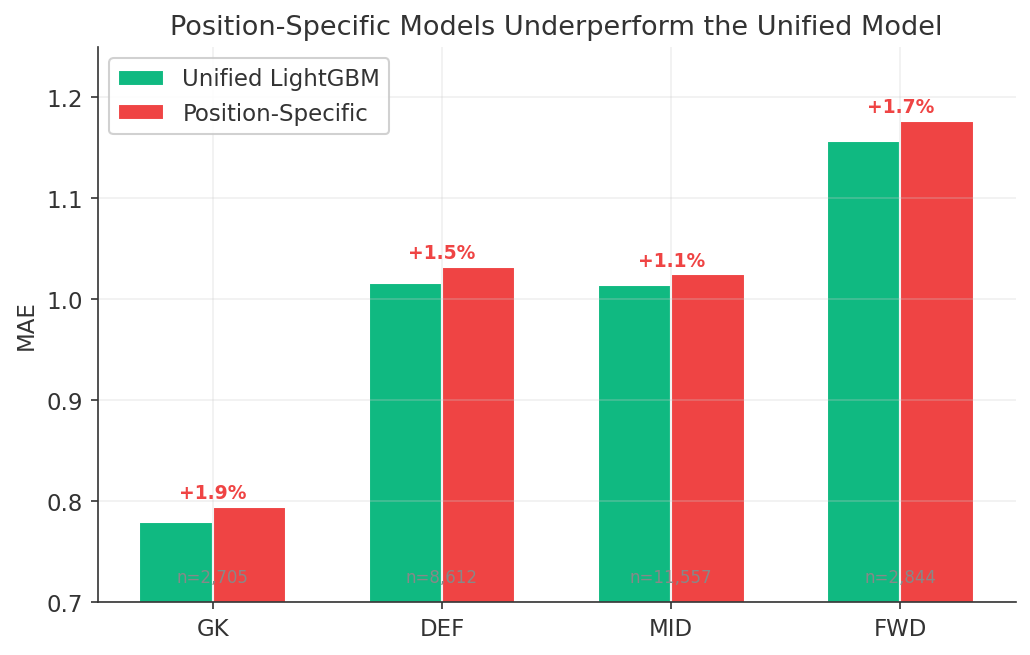

In [5]:
positions = ["GK", "DEF", "MID", "FWD"]
pp = pos_spec["comparison"]["per_position"]

single_maes = [pp[p]["single"]["mae"] for p in positions]
posspec_maes = [pp[p]["position_specific"]["mae"] for p in positions]
samples = [pp[p]["n_samples"] for p in positions]

x = np.arange(len(positions))
w = 0.32

fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar(x - w/2, single_maes, w, label="Unified LightGBM", color=PAL[0], edgecolor="white")
b2 = ax.bar(x + w/2, posspec_maes, w, label="Position-Specific", color=PAL[3], edgecolor="white")

# annotate with delta
for i, (s, p) in enumerate(zip(single_maes, posspec_maes)):
    delta = ((p - s) / s) * 100
    y = max(s, p) + 0.008
    ax.text(i, y, f"+{delta:.1f}%", ha="center", fontsize=9, color=PAL[3], fontweight="bold")

# sample counts
for i, n in enumerate(samples):
    ax.text(i, 0.72, f"n={n:,}", ha="center", fontsize=8, color="#888888")

ax.set_ylabel("MAE")
ax.set_title("Position-Specific Models Underperform the Unified Model")
ax.set_xticks(x)
ax.set_xticklabels(positions)
ax.set_ylim(0.7, 1.25)
ax.legend(loc="upper left", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../outputs/figures/fig3_position_specific_vs_unified.png")
plt.show()

## Figure 4 — Two-Head Model: Hard vs Soft Combination

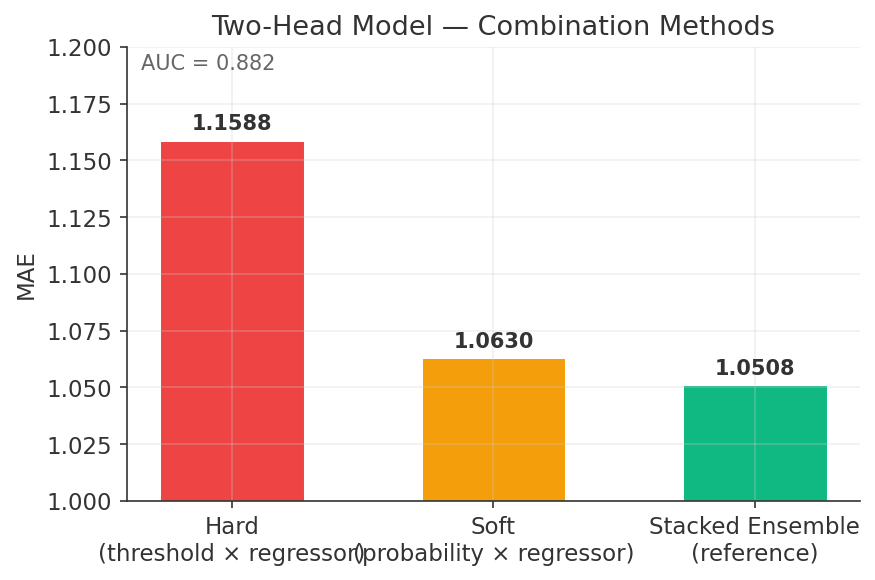

In [6]:
methods = ["Hard\n(threshold × regressor)", "Soft\n(probability × regressor)", "Stacked Ensemble\n(reference)"]
vals = [
    twohead["all_methods"]["hard"]["mae"],
    twohead["all_methods"]["soft"]["mae"],
    comp_stacked["stratified"]["mae_overall"],
]
cols = [PAL[3], PAL[2], PAL[0]]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(methods, vals, color=cols, width=0.55, edgecolor="white", linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.4f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.annotate(f"AUC = {twohead['classifier_auc']:.3f}", xy=(0.02, 0.95),
            xycoords="axes fraction", fontsize=10, color="#666666")

ax.set_ylabel("MAE")
ax.set_title("Two-Head Model — Combination Methods")
ax.set_ylim(1.0, 1.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../outputs/figures/fig4_twohead_comparison.png")
plt.show()

## Figure 5 — Ablation Study: Injury & News Feature Integration

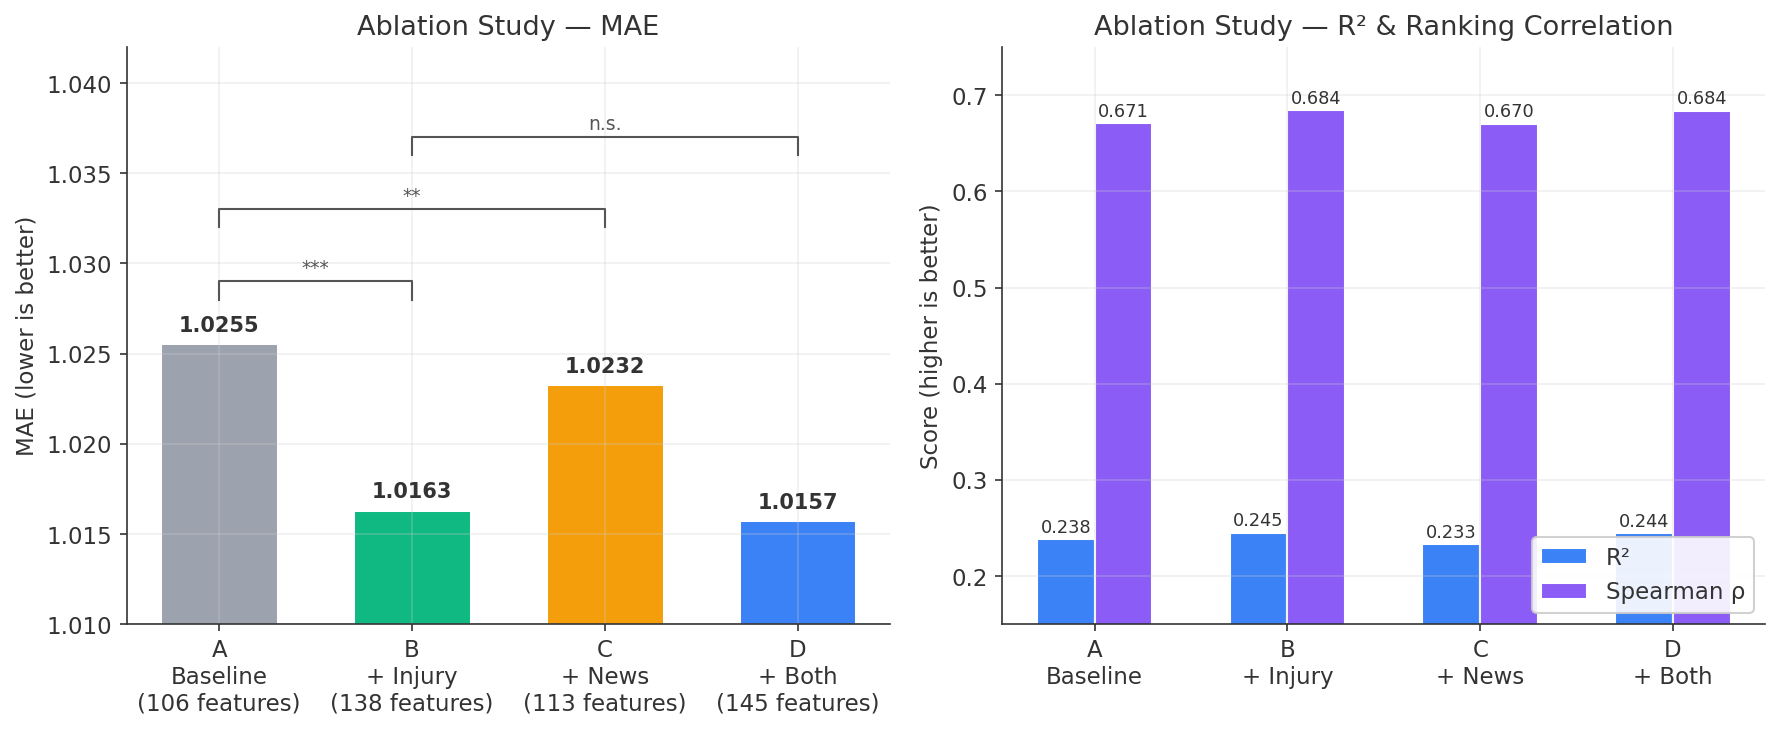

In [7]:
configs = ["A", "B", "C", "D"]
labels = [
    "A\nBaseline\n(106 features)",
    "B\n+ Injury\n(138 features)",
    "C\n+ News\n(113 features)",
    "D\n+ Both\n(145 features)",
]
a_mae  = [ablation[f"config_{c}"]["mae"] for c in configs]
a_r2   = [ablation[f"config_{c}"]["r2"] for c in configs]
a_rho  = [ablation[f"config_{c}"]["spearman_rho"] for c in configs]

# significance markers
sig = ablation["statistical_tests"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# left: MAE
ab_colors = ["#9CA3AF", PAL[0], PAL[2], PAL[1]]
bars1 = ax1.bar(labels, a_mae, color=ab_colors, width=0.6, edgecolor="white", linewidth=0.5)
for bar, v in zip(bars1, a_mae):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.0005, f"{v:.4f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

# significance brackets
def add_sig(ax, x1, x2, y, p, label):
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    ax.plot([x1, x1, x2, x2], [y, y+0.001, y+0.001, y], color="#555", lw=1)
    ax.text((x1+x2)/2, y+0.0012, f"{stars}", ha="center", va="bottom", fontsize=9, color="#555")

add_sig(ax1, 0, 1, 1.028, sig["A_vs_B"]["dm_p_value"], "A vs B")
add_sig(ax1, 0, 2, 1.032, sig["A_vs_C"]["dm_p_value"], "A vs C")
add_sig(ax1, 1, 3, 1.036, sig["B_vs_D"]["dm_p_value"], "B vs D")

ax1.set_ylabel("MAE (lower is better)")
ax1.set_title("Ablation Study — MAE")
ax1.set_ylim(1.010, 1.042)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# right: R² and Spearman rho
x = np.arange(len(configs))
w = 0.3
b_r2  = ax2.bar(x - w/2, a_r2, w, label="R²", color=PAL[1], edgecolor="white")
b_rho = ax2.bar(x + w/2, a_rho, w, label="Spearman ρ", color=PAL[4], edgecolor="white")

for bar, v in zip(b_r2, a_r2):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.3f}",
             ha="center", va="bottom", fontsize=8.5)
for bar, v in zip(b_rho, a_rho):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.3f}",
             ha="center", va="bottom", fontsize=8.5)

ax2.set_ylabel("Score (higher is better)")
ax2.set_title("Ablation Study — R² & Ranking Correlation")
ax2.set_xticks(x)
ax2.set_xticklabels(["A\nBaseline", "B\n+ Injury", "C\n+ News", "D\n+ Both"])
ax2.legend(loc="lower right", framealpha=0.9)
ax2.set_ylim(0.15, 0.75)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig("../outputs/figures/fig5_ablation_study.png")
plt.show()

## Figure 6 — SHAP Feature Importance (Top 15)

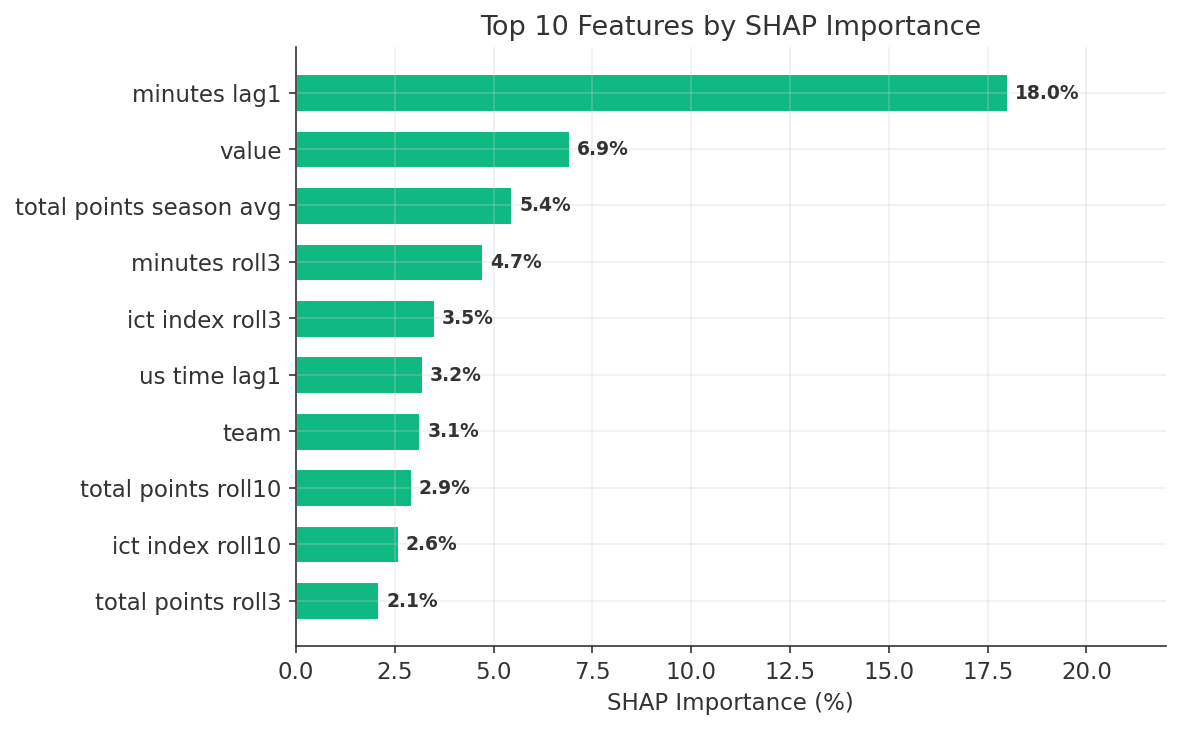

In [8]:
top10 = shap_data["global_importance"]["top_10"]
features = [f["feature"].replace("_", " ") for f in top10][::-1]
importances = [f["importance_pct"] for f in top10][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(features, importances, color=PAL[0], height=0.65, edgecolor="white", linewidth=0.5)

for bar, v in zip(bars, importances):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2, f"{v:.1f}%",
            va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("SHAP Importance (%)")
ax.set_title("Top 10 Features by SHAP Importance")
ax.set_xlim(0, 22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../outputs/figures/fig6_shap_feature_importance.png")
plt.show()

## Figure 7 — Per-Position MAE Across All Architectures

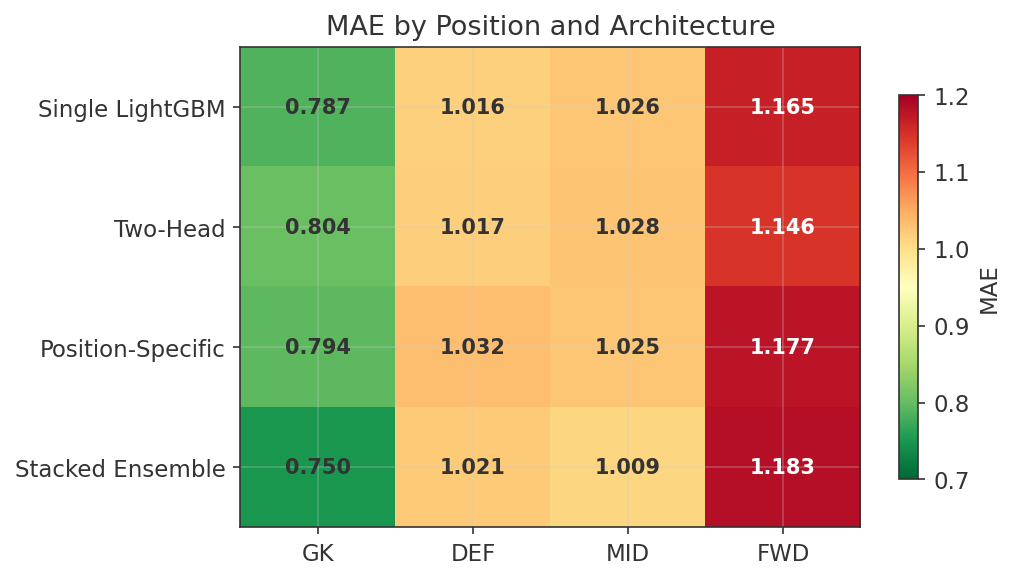

In [9]:
arch_names = ["Single LightGBM", "Two-Head", "Position-Specific", "Stacked Ensemble"]
pos_labels = ["GK", "DEF", "MID", "FWD"]

data = np.array([
    [comp_baseline["stratified"][f"mae_{p.lower()}"] for p in pos_labels],
    [comp_twohead["stratified"][f"mae_{p.lower()}"] for p in pos_labels],
    [comp_posspec["stratified"][f"mae_{p.lower()}"] for p in pos_labels],
    [comp_stacked["stratified"][f"mae_{p.lower()}"] for p in pos_labels],
])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(data, cmap="RdYlGn_r", aspect="auto", vmin=0.7, vmax=1.2)

ax.set_xticks(range(len(pos_labels)))
ax.set_xticklabels(pos_labels)
ax.set_yticks(range(len(arch_names)))
ax.set_yticklabels(arch_names)

for i in range(len(arch_names)):
    for j in range(len(pos_labels)):
        val = data[i, j]
        color = "white" if val > 1.05 else "#333333"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10, fontweight="bold", color=color)

ax.set_title("MAE by Position and Architecture")
cbar = fig.colorbar(im, ax=ax, shrink=0.8, label="MAE")
plt.tight_layout()
fig.savefig("../outputs/figures/fig7_position_mae_heatmap.png")
plt.show()

## Figure 8 — Ablation: Interaction Effect (Injury × News)

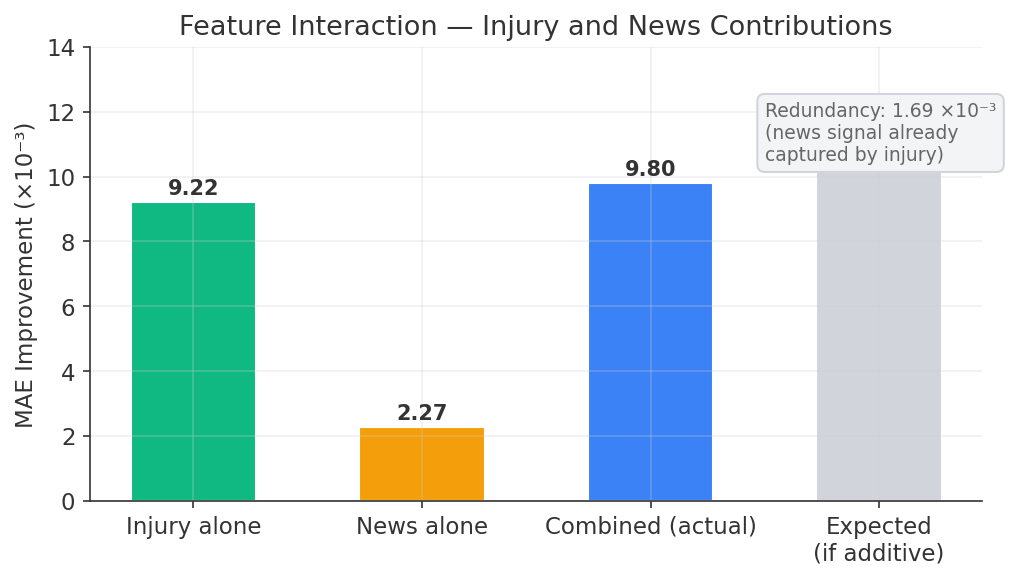

In [10]:
interaction = ablation["statistical_tests"]["interaction"]

contributions = {
    "Injury alone": interaction["injury_alone"] * 1000,
    "News alone": interaction["news_alone"] * 1000,
    "Combined (actual)": interaction["combined"] * 1000,
    "Expected\n(if additive)": (interaction["injury_alone"] + interaction["news_alone"]) * 1000,
}
cols = [PAL[0], PAL[2], PAL[1], "#D1D5DB"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contributions.keys(), contributions.values(), color=cols, width=0.55, edgecolor="white")

for bar, v in zip(bars, contributions.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f"{v:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

# annotation for redundancy
redundancy = -interaction["interaction"] * 1000
ax.annotate(f"Redundancy: {redundancy:.2f} ×10⁻³\n(news signal already\ncaptured by injury)",
            xy=(2.5, 10.5), fontsize=9, color="#666666",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#F3F4F6", edgecolor="#D1D5DB"))

ax.set_ylabel("MAE Improvement (×10⁻³)")
ax.set_title("Feature Interaction — Injury and News Contributions")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 14)
plt.tight_layout()
fig.savefig("../outputs/figures/fig8_ablation_interaction.png")
plt.show()

## Figure 9 — Calibration: Decile MAE (Stacked Ensemble)

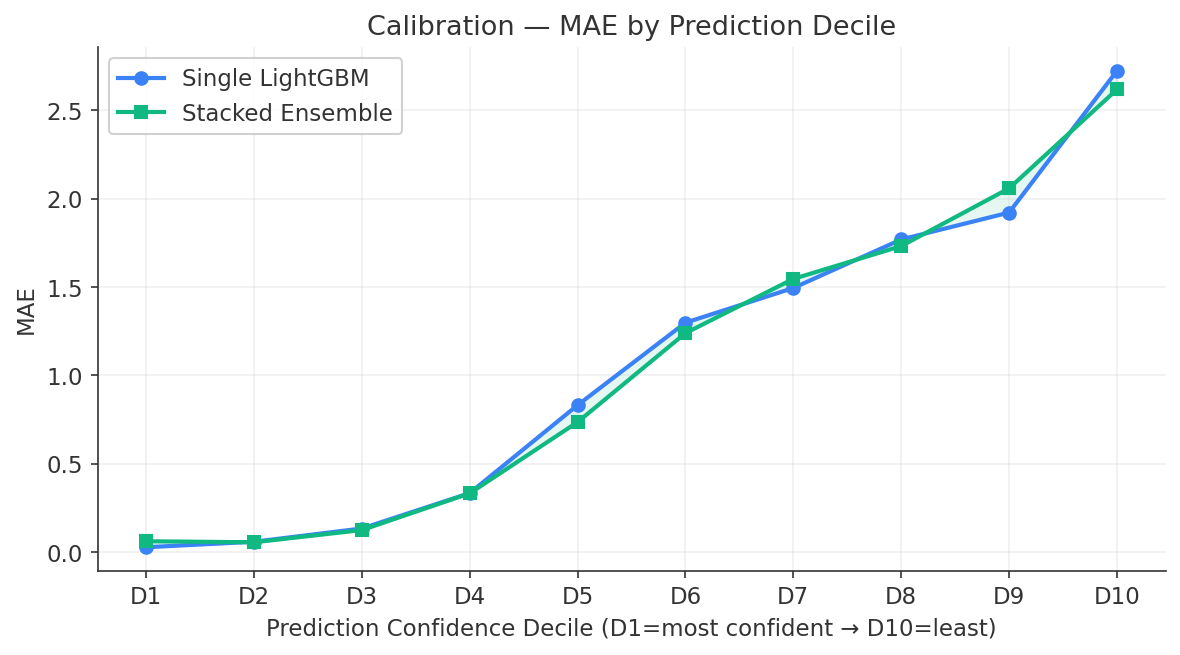

In [11]:
deciles_baseline = comp_baseline["calibration"]["decile_mae"]
deciles_stacked  = comp_stacked["calibration"]["decile_mae"]
decile_labels = [f"D{i+1}" for i in range(10)]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(10)
ax.plot(x, deciles_baseline, "o-", color=PAL[1], label="Single LightGBM", markersize=6, linewidth=2)
ax.plot(x, deciles_stacked, "s-", color=PAL[0], label="Stacked Ensemble", markersize=6, linewidth=2)

ax.fill_between(x, deciles_baseline, deciles_stacked, alpha=0.1, color=PAL[0])

ax.set_xticks(x)
ax.set_xticklabels(decile_labels)
ax.set_xlabel("Prediction Confidence Decile (D1=most confident → D10=least)")
ax.set_ylabel("MAE")
ax.set_title("Calibration — MAE by Prediction Decile")
ax.legend(loc="upper left", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../outputs/figures/fig9_calibration_decile.png")
plt.show()

## Summary

| Figure | What it shows |
|--------|---------------|
| Fig 1 | Architecture comparison — Stacked Ensemble wins (MAE 1.0508) |
| Fig 2 | Base model breakdown — Ridge and RF get highest meta-weights |
| Fig 3 | Position-specific loses everywhere — data splitting hurts |
| Fig 4 | Two-Head soft > hard, but still below ensemble |
| Fig 5 | Ablation — Injury features help (p<0.001), news adds little over injury |
| Fig 6 | SHAP — minutes_lag1 dominates at 18% |
| Fig 7 | Position × Architecture heatmap — FWD hardest, GK easiest |
| Fig 8 | Interaction effect — news signal is redundant with injury |
| Fig 9 | Calibration — ensemble better at confident predictions |

All figures saved to `outputs/figures/`.